<a href="https://colab.research.google.com/github/LIBY70/Data-Analysis/blob/main/hw2_22012167_%EB%85%B8%EC%A3%BC%ED%98%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

문제 1.

1~10 정수에서 랜덤하게 뽑아 구성한 3 by 4 matrix를 만들고, 각 열 별로 평균
(μ)과 표준편차(σ)를 구한 뒤, 각 열 별로 해당 μ - σ 보다 큰 element의 개수를 구하시오.

In [1]:
import numpy as np

#1~10 사이의 정수로 구성된 3x4 행렬 생성
data = np.random.randint(1, 11, size=(3, 4))
data

array([[ 1,  8,  9,  8],
       [ 7,  2, 10,  7],
       [ 1,  5,  8, 10]])

In [2]:
#평균
mean = np.mean(data, axis=0)
mean

array([3.        , 5.        , 9.        , 8.33333333])

In [3]:
##표준편차
std = np.std(data, axis=0)
std

array([2.82842712, 2.44948974, 0.81649658, 1.24721913])

In [4]:
#평균 - 표준편차 값보다 큰 요소의 개수
count = data > (mean - std)
count = np.sum(count, axis = 0)
count

array([3, 2, 2, 2])

문제 2. pandas_data1.txt를 읽어서 다음을 출력하시오 (‘이름’을 index로 선택).
1) 이여섯, 최아홉 학생의 기말점수 (DataFrame 형태로)
2) 마지막 6명 학생의 출석, 과제 점수

In [5]:
import pandas as pd

df = pd.read_csv('pandas_data1.txt', sep='\t', index_col='이름', encoding='euc-kr')
df

,성별,학년,중간,기말,출석,과제
이름,,,,,,
김둘,여자,1.0,NaN,36,5,75
김셋,남자,2.0,17.0,20,5,96
김여섯,남자,2.0,28.0,20,4,83
김일곱,남자,NaN,20.0,44,6,82
김여덜,NaN,1.0,20.0,24,8,88
김아홉,남자,3.0,23.0,45,10,92
김열,남자,3.0,16.0,47,5,83
이다섯,남자,3.0,21.0,35,5,92
이아홉,남자,3.0,20.0,36,5,87


In [6]:
df1 = df.loc[['이여섯','최아홉'], ['기말']]
df1

,기말
이름,
이여섯,38
최아홉,33


In [24]:
df2 = df.iloc[-6:,-2:]
df2

,출석,과제
이름,,
김넷,7,93
김다섯,6,84
이하나,5,79
이둘,8,98
이셋,4,79
이넷,10,89


In [26]:
df2 = df.iloc[-6:][['과제','출석']]
df2

,과제,출석
이름,,
김넷,93,7
김다섯,84,6
이하나,79,5
이둘,98,8
이셋,79,4
이넷,89,10


In [22]:
df2 = df.loc['김넷':,['과제', '출석']]
df2

,과제,출석
이름,,
김넷,93,7
김다섯,84,6
이하나,79,5
이둘,98,8
이셋,79,4
이넷,89,10


 문제 3. pandas_data2.txt를 DataFrame으로 읽고, 아래를 수행하시오.
 1) proj가 90점 이상인 학생들의 mid 점수의 평균을 구하시오.
 2) final_HML colum을 만들어서,
 - final_mean+3 보다 큰 final 점수는 H
 - final_mean-3 보다 작은 final 점수는 L
 - 아니면 M으로 넣으시오.

In [ ]:
df3 = pd.read_csv('pandas_data1.txt', sep='\t', index_col='이름', encoding='euc-kr')

students = df3[df3['과제'] >= 90][['중간']]
mean = students.mean()
print(mean['중간'])

21.25


Numpy의 select 사용

In [ ]:
mean = df3['기말'].mean()
final_mean_plus_3 = mean + 3
final_mean_minus_3 = mean - 3

conditions = [
    df3['기말'] > final_mean_plus_3,
    df3['기말'] < final_mean_minus_3
]
choices = ['H', 'L']

df3['final_HML'] = np.select(conditions, choices, default='M')
df3['final_HML']

,final_HML
이름,
김둘,M
김셋,L
김여섯,L
김일곱,H
김여덜,L
김아홉,H
김열,H
이다섯,M
이아홉,M


loc으로 초기화

In [ ]:
final_mean = df3['기말'].mean()
final_mean_plus_3 = final_mean + 3
final_mean_minus_3 = final_mean - 3

df3['final_HML'] = 'M'

df3.loc[df3['기말'] > final_mean_plus_3, 'final_HML'] = 'H'

df3.loc[df3['기말'] < final_mean_minus_3, 'final_HML'] = 'L'
df3['final_HML']

,final_HML
이름,
김둘,M
김셋,L
김여섯,L
김일곱,H
김여덜,L
김아홉,H
김열,H
이다섯,M
이아홉,M


- X ➔ [0,1,2,3,4]에서 random하게 값 3개를 추출 (비복원추출)
- Y ➔ [0,1,2,3,4]에서 random하게 값 3개를 추출 (비복원추출)
- X, Y의 각 값을 pair로 하는 3개의 점을 plot하는데,
x값+y값이 짝수이면 빨간색 동그라미를, 홀수이면 파란색 십자가를 그리시오

X 값: [4 0 2]
Y 값: [1 0 4]


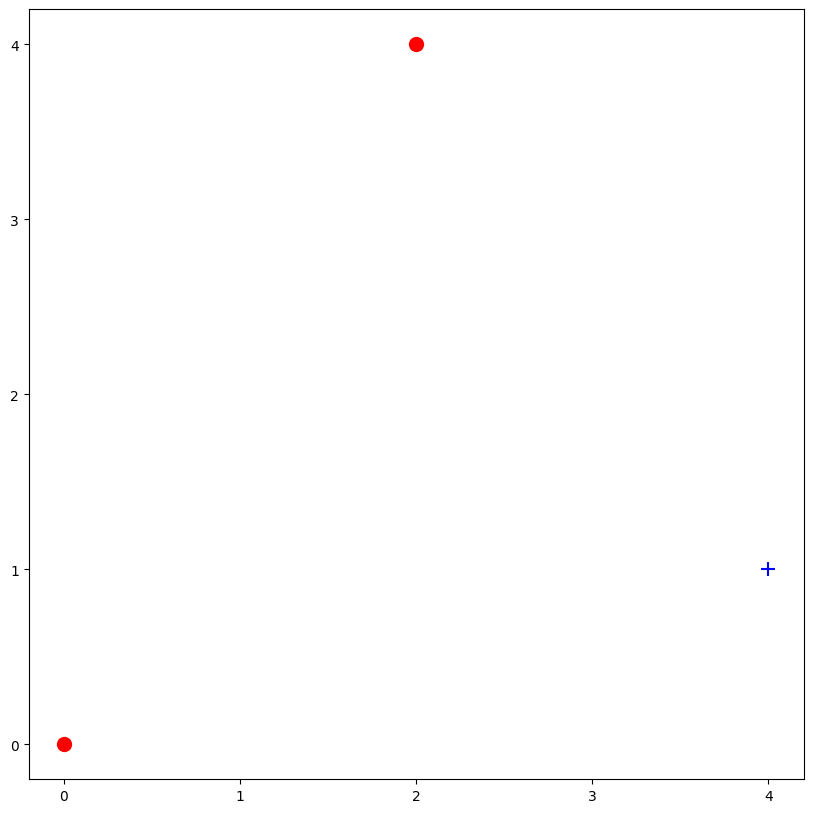

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 0부터 4까지의 정수에서 3개씩 비복원 추출
x = np.random.choice(range(5), size=3, replace=False)
y = np.random.choice(range(5), size=3, replace=False)

print(f"X 값: {x}")
print(f"Y 값: {y}")

plt.figure(figsize=(10, 10))
plt.xticks(range(5))
plt.yticks(range(5))
plt.grid(False)

for i in range(3):
   X = x[i]
   Y = y[i]

   if (X + Y) % 2 == 0:
        plt.scatter(X, Y, color='red', marker='o', s=100)
   else:
        plt.scatter(X, Y, color='blue', marker='+', s=100)

plt.show()